# Sentinel-2 NDMI/GNDVI analysis

Reproducible analysis accompanying:
[manuscript citation]

## Analysis workflow

1. Define Sentinel-2 acquisitions and study AOIs
2. Extract NDMI and GNDVI from each AOI
3. Identify cloudy acquisitions
4. Plot time series and weather data
5. Define dry seasons (1 March–30 June)
6. Perform BACI comparisons
7. Export manuscript analysis tables

In [21]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 14] n_cols in ConstantObjects: 21
[Line 16] n_cols: 21, n_rows: 18
[Line 27] n_cols in ConstantObjects: 21
[Line 29] gdf_tree_circles.shape: (378, 1)
x0 =  -66983.49795860096
y0 =  6798562.116878612
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.990025, -0.599702)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777201, -96.871090)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246395.5503548854
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.778652, -96.863761)
x0 =  -68796.33586616941
y0 =  6799925.297074551
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center 

In [41]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here
#Some Sentinel2 overflight dates in veracruz are 2021-01-13 , 2022-01-13  2024-01-13, 2025-01-12
startDate = "2026-06-01"
startDate = "2022-01-13"

#startDate = "2022-01-13"
startDate = "2022-03-04"

endDate = "2026-08-31"

# Villanueva, VER
#startDate = "2025-01-12"
#endDate = "2025-08-16"
#ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"


dates = Utils.generate_date_range(startDate, endDate, Constants.lat0, Constants.lon0, "%Y-%m-%d")
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")

    if not os.path.exists(ndmi_tile_tif) or not os.path.exists(gndvi_tile_tif):
        print(
            f"Skipping {date}: derived NDMI/gNDVI missing "
            "(likely no Sentinel-2 acquisition for this tile/date)."
        )
        continue

    # The tile file may exist while this AOI lies in a black/no-data swath.
    ndmi_valid = Utils.valid_index_pixels_in_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa)
    gndvi_valid = Utils.valid_index_pixels_in_gdf(gndvi_tile_tif, ConstantObjects.gdf_box_terreno_casa)
    if ndmi_valid == 0 or gndvi_valid == 0:
        print(f"Skipping {date}: no valid pixels over the AOI "
              f"(NDMI={ndmi_valid}, GNDVI={gndvi_valid}).")
        continue

    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi-terreno-casa","tif")
    ndmi_plots_2_3_1A_1B_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "plots_2_3_1A_1B","tif")
    ndmi_casa_y_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "casa_y_vecino","tif")

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_terreno_casa_tif = ",ndmi_terreno_casa_tif)    
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    if any(band_stats["valid_pixels"] == 0 for band_stats in (
        b2_intensity_terreno_casa, b3_intensity_terreno_casa, b4_intensity_terreno_casa
    )):
        print(f"Skipping {date}: an RGB band has no valid pixels over the AOI.")
        continue
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b4_norm_reflectance_terreno_casa)/3 
    cloudy =0
    if (red_green_blue_average) > 3500:  cloudy = 1
    if cloudy:
        print(f"Skipping {date}: RGB average {red_green_blue_average:.1f} "
              "exceeds the cloud threshold .")
        continue


    print(
        date,
        "RGB avg =", red_green_blue_average,
        "cloudy =", cloudy,
        "NDMI exists =", os.path.exists(ndmi_tile_tif),
        "gNDVI exists =", os.path.exists(gndvi_tile_tif)
    )
    
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa, ndmi_terreno_casa_tif) ")
    stats_terreno_casa = {
        "count_valid": 0,
        "mean": float("nan"),
        "median": float("nan"),
    }
    stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")
    stats_casa_y_vecino = Utils.crop_ndmi_to_gdf(
        ndmi_tile_tif, ConstantObjects.gdf_box_casa_y_vecino, ndmi_casa_y_vecino_tif
    )
    if stats_casa_y_vecino["count_valid"] == 0:
        print(f"Skipping {date}: neighboring AOI has no valid NDMI pixels.")
        continue

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over neighboring AOI:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)

    
    try:
        ndmi_plots_4_5_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      ndmi_tile_tif, "ndmi_plots_4_5",       date, cloudy)
        ndmi_plots_2_3_1A_1B_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,ndmi_tile_tif, "ndmi_plots_2_3_1A_1B", date, cloudy)
        ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
        #ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
        ndmi_milpa_vecino_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,   ndmi_tile_tif, "ndmi_milpa_vecino",    date, cloudy)
        ndmi_terreno_casa_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_terreno_casa,   ndmi_tile_tif, "ndmi_terreno_casa",    date, cloudy)
        gndvi_plots_4_5_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      gndvi_tile_tif,"gndvi_plots_4_5",      date, cloudy)
        gndvi_plots_2_3_1A_1B_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,gndvi_tile_tif,"gndvi_plots_2_3_1A_1B",date, cloudy)
        gndvi_milpa1_stats         =  Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)
        gndvi_milpa_vecino_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)
    except ValueError as e:
        if "AOI does not overlap the raster" in str(e):
            print(f"Skipping {date}: {e}")
            continue
        raise
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_4_5_stats.get(mean,   np.nan) = ",gndvi_plots_4_5_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_2_3_1A_1B_stats.get(mean,   np.nan) = ",gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan))

    gndvi_reference = gndvi_milpa_vecino_stats.get("mean",   np.nan)
    ndmi_reference  = ndmi_milpa_vecino_stats.get("mean",   np.nan)
    
    print("NDMI 4/5:", ndmi_plots_4_5_stats.get("mean"))
    print("NDMI vecino:", ndmi_milpa_vecino_stats.get("mean"))
    print("gNDVI 4/5:", gndvi_plots_4_5_stats.get("mean"))
    print("gNDVI vecino:", gndvi_milpa_vecino_stats.get("mean"))

    rows.append({
        "date": date,
        "ndmi_terreno_casa":      ndmi_terreno_casa_stats.get("mean", np.nan),
        # Now making measurements relative to milpa_vecino
        "gndvi_plots_4_5":        gndvi_plots_4_5_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_plots_2_3_1A_1B":  gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_milpa1":           gndvi_milpa1_stats.get("mean",   np.nan)-gndvi_reference,

        "gndvi_milpa_vecino":     gndvi_milpa_vecino_stats.get("mean",   np.nan)-gndvi_reference,
        
        "ndmi_plots_4_5":         ndmi_plots_4_5_stats.get ("mean",   np.nan)-ndmi_reference,
        "ndmi_plots_2_3_1A_1B":   ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-ndmi_reference,
        "ndmi_milpa1":            ndmi_milpa1_stats.get("mean",   np.nan)-ndmi_reference,

        "ndmi_milpa_vecino":      ndmi_milpa_vecino_stats.get("mean",   np.nan)-ndmi_reference,
        
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])
    #print(f"Cell [Line {inspect.currentframe().f_lineno}] ... stats_milpa_vecino.get(mean,   np.nan)  ",stats_milpa_vecino.get("mean",   np.nan))

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 14] n_cols in ConstantObjects: 21
[Line 16] n_cols: 21, n_rows: 18
[Line 27] n_cols in ConstantObjects: 21
[Line 29] gdf_tree_circles.shape: (378, 1)
x0 =  -66983.49795860096
y0 =  6798562.116878612
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (51.990025, -0.599702)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.777201, -96.871090)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246395.5503548854
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (19.778652, -96.863761)
x0 =  -68796.33586616941
y0 =  6799925.297074551
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center 

[Line 506] ... Mapped latitude  19.7782 , longitude  -96.86942  to mgrs_tile =  14QQG
First acquisition: 2022-03-04
[Line 38] ...   
Cell [Line 43] ... dates =  ['2022-03-04', '2022-03-09', '2022-03-14', '2022-03-19', '2022-03-24', '2022-03-29', '2022-04-03', '2022-04-08', '2022-04-13', '2022-04-18', '2022-04-23', '2022-04-28', '2022-05-03', '2022-05-08', '2022-05-13', '2022-05-18', '2022-05-23', '2022-05-28', '2022-06-07', '2022-06-12', '2022-06-17', '2022-06-22', '2022-06-27', '2022-07-02', '2022-07-07', '2022-07-12', '2022-07-17', '2022-07-22', '2022-07-27', '2022-08-01', '2022-08-06', '2022-08-11', '2022-08-16', '2022-08-21', '2022-08-26', '2022-08-31', '2022-09-05', '2022-09-10', '2022-09-15', '2022-09-20', '2022-09-25', '2022-09-30', '2022-10-05', '2022-10-10', '2022-10-15', '2022-10-20', '2022-10-25', '2022-10-30', '2022-11-04', '2022-11-09', '2022-11-14', '2022-11-19', '2022-11-24', '2022-11-29', '2022-12-04', '2022-12-09', '2022-12-14', '2022-12-19', '2022-12-24', '2022-12-29'

In [42]:
importlib.reload(Utils)

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

api_key = "E6RKNQ36BSLC8EUK5S3C5AKUQ"
location = str(Constants.lat0)+","+str(Constants.lon0) #"19.777411,-96.870102"  # Change location as needed
unit_group = "metric" 

visualcrossing_dict = Utils.fetch_weather_data(api_key, location, startDate, endDate, unit_group)

print ("**********************")

print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
precip_df.head()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 6] .. df =            date  ndmi_terreno_casa  gndvi_plots_4_5  gndvi_plots_2_3_1A_1B  \
0   2022-03-04           0.122034         0.066858               0.091638   
1   2022-03-14           0.158439         0.079507               0.091697   
2   2022-03-29           0.147228         0.047186               0.000230   
3   2022-04-13           0.192504         0.020770               0.010388   
4   2022-04-23           0.179489         0.001171               0.000637   
..         ...                ...              ...                    ...   
79  2026-06-01           0.183744         0.035918               0.096036   
80  2026-06-06           0.229993         0.008239               0.059183   
81  2026-06-16           0.255134         0.043140               0.083501   
82  2026-06-21           0.264643         0.229865               0.244934   
83  2026-06-26           0.259692         0.059994               0.060382   

    gndvi_milpa1  gndvi_milpa_vecino  ndmi_plots_4_5

2022 dry-season mean temperature = 22.860504201680676 mean precipitation = 3.3789915966386563
2023 dry-season mean temperature = 23.11967213114754 mean precipitation = 4.533606557377049
2024 dry-season mean temperature = 23.46065573770492 mean precipitation = 5.044262295081967
2025 dry-season mean temperature = 21.024590163934423 mean precipitation = 5.753278688524591
2026 dry-season mean temperature = 23.06065573770492 mean precipitation = 4.072131147540984
2022 longest dry spell: 15 days, 2022-04-04 to 2022-04-18
2023 longest dry spell: 14 days, 2023-06-10 to 2023-06-23
2024 longest dry spell: 40 days, 2024-05-01 to 2024-06-09
2025 longest dry spell: 19 days, 2025-03-01 to 2025-03-19
2026 longest dry spell: 10 days, 2026-04-22 to 2026-05-01
for plot  gndvi_plots_4_5  my_plot_std_dev =  0.07739713625121872
[Cell Line 34] .. my_plot_avg=  0.027537983135462102
SSEDA = [(Timestamp('2026-03-01 00:00:00'), Timestamp('2026-06-30 00:00:00'), Timestamp('2026-04-30 12:00:00'))]
for plot  gndvi

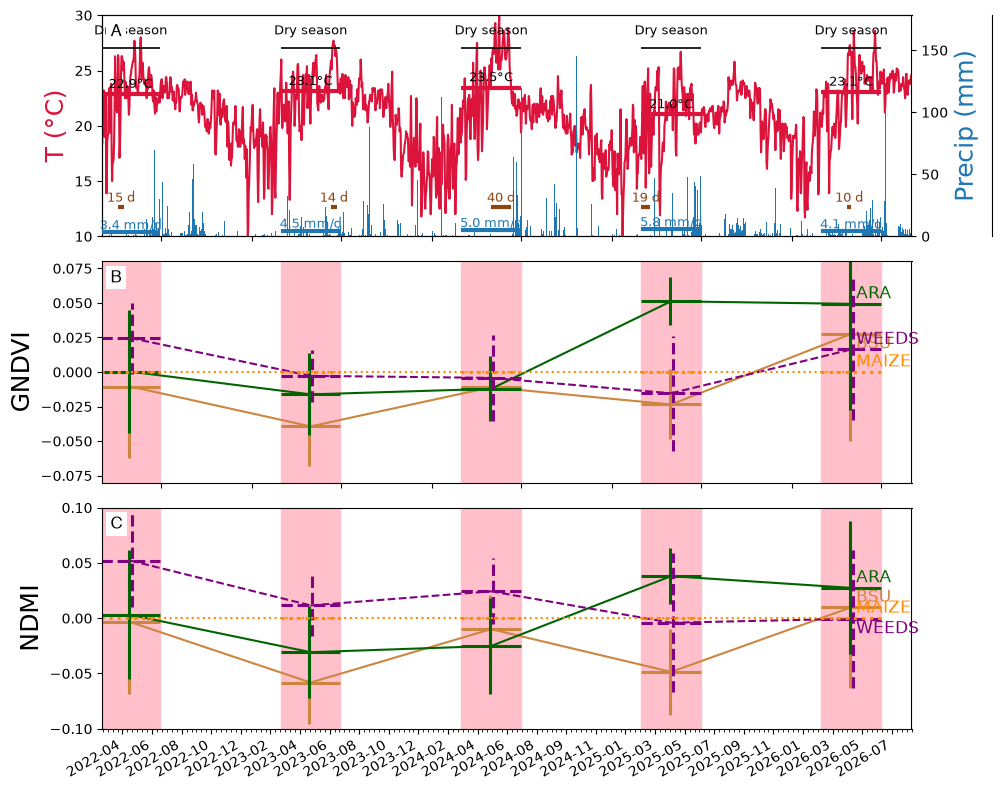

Area of Weeds =  0    8095.203644
dtype: float64  << 
Area of Milpa2 =  0    2623.766942
dtype: float64  << 
Area of terreno_casa =  0    6759.659362
dtype: float64  << 
Area of ARA =  0    1192.881075
dtype: float64  << 
Area of BSU =  0    397.627025
dtype: float64  << 
Area of MAIZE =  0    7097.642656
dtype: float64  << 
in units of :  metre


In [64]:
import MatPlotLibUtils
importlib.reload(MatPlotLibUtils)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(MatPlotLibUtils)
import  datetime as _dt
from datetime import datetime, timedelta
import pandas
import geopandas as gpd

display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"


# Match Figure 9 treatment styling
ara_style = dict(
    color="darkgreen",
    linestyle="-",
    linewidth=2.5,
    marker="o",
    markersize=4
)

bsu_style = dict(
    color="peru",
    linestyle="-",
    linewidth=1.5,
    marker="s",
    markersize=4
)

weeds_style = dict(
    color="purple",
    linestyle="--",
    linewidth=1.5,
    marker="^",
    markersize=4
)

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, axes = plt.subplots(3,figsize=(10, 8))
# NDMI lines (sparse dates)
ax=axes[0]


minTemp = 10
maxTemp = 30
myfontsize = 18
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
#ax.plot(visualcrossing_dict['datetime'], visualcrossing_dict["temp"],lw=1.5, label="T (°C)") 
dates = [datetime.strptime( day['datetime'], "%Y-%m-%d") for day in visualcrossing_dict['days']]
temperatures = [day['temp'] for day in visualcrossing_dict['days']]
precipitations = [day['precip'] for day in visualcrossing_dict['days']]
ax.plot(dates, temperatures,lw=1.5, label="T (°C)",color=temperature_color) 
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)
MatPlotLibUtils.indicate_seasons(startDate,endDate, ax,"Dry season")

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
ax2.bar(dates, precipitations,label="Precipitation (mm)",color=precip_color)


MatPlotLibUtils.plot_season_climate_averages(
    startDate,
    endDate,
    dates,
    temperatures,
    precipitations,
    ax,
    ax2,
    temp_color=temperature_color,
    precip_color=precip_color
)
MatPlotLibUtils.plot_longest_dry_spells(
    startDate,
    endDate,
    dates,
    precipitations,
    ax2,
    dry_threshold=1.0,
    y_position=24,
    my_color="saddlebrown",
    annotate=True
)

axes[2].set_ylabel("NDMI",fontsize = myfontsize)
#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)

ymin=-0.1
ymax=.1
axes[1].set_ylim(-.08, .08) 
axes[2].set_ylim(-.1, .1)
MatPlotLibUtils.indicate_seasons_box(startDate,endDate , axes[1],my_label="Dry season",my_color="pink",line_style="none")
MatPlotLibUtils.indicate_seasons_box(startDate,endDate,  axes[2],my_label="Dry season",my_color="pink",line_style="none")


axes[1].set_ylabel("Vegetation",fontsize = myfontsize)
axes[1].set_ylabel("GNDVI",fontsize = myfontsize)



#axes[1].set_ylim([-.1, .1])
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_plots_4_5",      axes[1],bsu_style["color"], bsu_style["linestyle"],"BSU",-3,"top")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_plots_2_3_1A_1B",axes[1],ara_style["color"], ara_style["linestyle"],"ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_milpa1"  ,       axes[1],weeds_style["color"],weeds_style["linestyle"],"WEEDS",3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_milpa_vecino",   axes[1],"darkorange","dotted","MAIZE",0,"center")

#stat sig difference between +-COVER
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_plots_4_5"      ,axes[2],bsu_style["color"], bsu_style["linestyle"],"BSU",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_plots_2_3_1A_1B",axes[2],ara_style["color"], ara_style["linestyle"],"ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_milpa1"         ,axes[2],weeds_style["color"],weeds_style["linestyle"],"WEEDS",3,"top")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_milpa_vecino"   ,axes[2],"darkorange","dotted","MAIZE",0,"center")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
axes[2].set_xlim(xmin, xmax)

axes[2].xaxis.set_minor_locator(mdates.DayLocator(interval=10))   # tick every 5 days
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=60)) 
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

axes[0].annotate("A", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[1].annotate("B", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[2].annotate("C", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("NDMI-gNDVI-precip-temp-vs-time", dpi=300, bbox_inches="tight")

print ("Area of Weeds = ", (ConstantObjects.gdf_plotMilpa1.to_crs(epsg=3395)).area, " << ")
print ("Area of Milpa2 = ", (ConstantObjects.gdf_plotMilpa2.to_crs(epsg=3395)).area, " << ")
print ("Area of terreno_casa = ", (ConstantObjects.gdf_box_terreno_casa.to_crs(epsg=3395)).area, " << ")
print ("Area of ARA = ", (ConstantObjects.gdf_box_plots_2_3_1A_1B.to_crs(epsg=3395)).area, " << ")
print ("Area of BSU = ", (ConstantObjects.gdf_box_plots_4_5.to_crs(epsg=3395)).area, " << ")
print ("Area of MAIZE = ", (ConstantObjects.gdf_box_milpa_vecino.to_crs(epsg=3395)).area, " << ")
print ("in units of : ",(ConstantObjects.gdf_plotMilpa1.to_crs(epsg=3395)).crs.axis_info[0].unit_name)


2025 dry-season mean temperature = 21.024590163934423 mean precipitation = 5.753278688524591
2025 longest dry spell: 19 days, 2025-03-01 to 2025-03-19
NDMI paired observations: 18
NDMI variance ARA:       0.000655
NDMI variance BSU:       0.001518
NDMI covariance ARA-BSU: 0.000352
Variance for paired NDMI_ARA - NDMI_BSU: 0.0014679440826969137
Variance for unpaired NDMI_ARA - NDMI_BSU: 0.002172406036656126


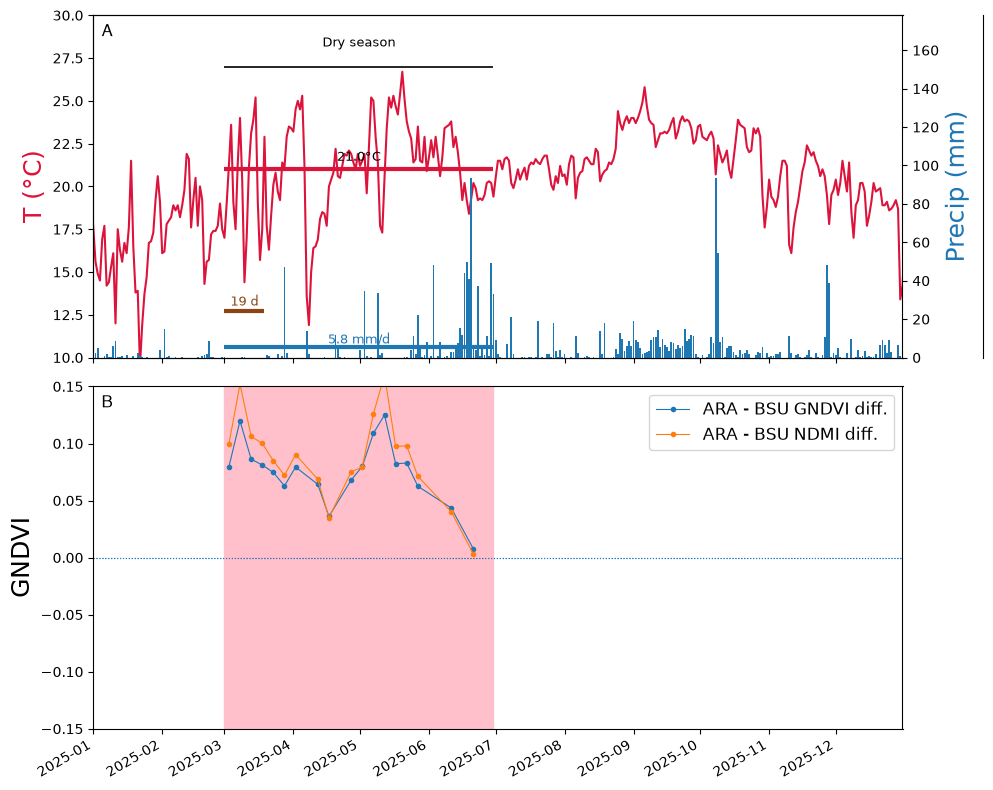

In [44]:
import MatPlotLibUtils
importlib.reload(MatPlotLibUtils)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(MatPlotLibUtils)
import  datetime as _dt
from datetime import datetime, timedelta
import pandas
import geopandas as gpd

startDate2025 = "2025-01-01"
endDate2025 = "2025-12-31"



display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, axes = plt.subplots(2,figsize=(10, 8))
# NDMI lines (sparse dates)
ax=axes[0]


minTemp = 10
maxTemp = 30
myfontsize = 18
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
#ax.plot(visualcrossing_dict['datetime'], visualcrossing_dict["temp"],lw=1.5, label="T (°C)") 
dates = [datetime.strptime( day['datetime'], "%Y-%m-%d") for day in visualcrossing_dict['days']]
temperatures = [day['temp'] for day in visualcrossing_dict['days']]
precipitations = [day['precip'] for day in visualcrossing_dict['days']]
ax.plot(dates, temperatures,lw=1.5, label="T (°C)",color=temperature_color) 
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
ax.set_frame_on(True); ax.patch.set_visible(False)
MatPlotLibUtils.indicate_seasons(startDate2025,endDate2025, ax,"Dry season")

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
ax2.bar(dates, precipitations,label="Precipitation (mm)",color=precip_color)


MatPlotLibUtils.plot_season_climate_averages(
    startDate2025,
    endDate2025,
    dates,
    temperatures,
    precipitations,
    ax,
    ax2,
    temp_color=temperature_color,
    precip_color=precip_color
)
MatPlotLibUtils.plot_longest_dry_spells(
    startDate2025,
    endDate2025,
    dates,
    precipitations,
    ax2,
    dry_threshold=1.0,
    y_position=24,
    my_color="saddlebrown",
    annotate=True
)

#axes[2].set_ylabel("NDMI",fontsize = myfontsize)

ymin=-0.1
ymax=.1
axes[1].set_ylim(-.15, .15) 
#axes[2].set_ylim(-.1, .1)
MatPlotLibUtils.indicate_seasons_box(startDate2025,endDate2025 , axes[1],my_label="Dry season",my_color="pink",line_style="none")
#MatPlotLibUtils.indicate_seasons_box(startDate2025,endDate2025,  axes[2],my_label="Dry season",my_color="pink",line_style="none")


axes[1].set_ylabel("Vegetation",fontsize = myfontsize)
axes[1].set_ylabel("GNDVI",fontsize = myfontsize)

#axes[0].plot(df["date"], df["gndvi_plots_4_5"],
#             marker="o", label="BSU")
#axes[0].plot(df["date"], df["gndvi_plots_2_3_1A_1B"],
#             marker="o", label="ARA")



# Raw acquisition-by-acquisition GNDVI difference: ARA - BSU
df2025 = df.loc[
    (df["date"] >= pandas.Timestamp(startDate2025)) &
    (df["date"] <= pandas.Timestamp(endDate2025))
].copy()

gndvi_diff = (
    df2025["gndvi_plots_2_3_1A_1B"]
    - df2025["gndvi_plots_4_5"]
)

axes[1].plot(
    df2025["date"],
    gndvi_diff,
    marker="o",
    markersize=3,
    linewidth=0.8,
    linestyle="-",
    label="ARA - BSU GNDVI diff."
)

axes[1].axhline(0, linewidth=0.8, linestyle=":")

# Raw acquisition-by-acquisition NDMI difference: ARA - BSU
ndmi_diff = (
    df2025["ndmi_plots_2_3_1A_1B"]
    - df2025["ndmi_plots_4_5"]
)

# --- Variance and covariance of paired ARA - BSU differences

# Combine the two difference series so that covariance uses only
# acquisitions where both NDMI and GNDVI are available.
diff_stats = pandas.DataFrame({
    "GNDVI_diff": gndvi_diff,
    "NDMI_diff": ndmi_diff
}).dropna()


########
# Determine potential for reducing statistical noise by pairing:
ndmi_stats = df2025[
    [
        "ndmi_plots_2_3_1A_1B",
        "ndmi_plots_4_5"
    ]
].dropna()

ndmi_ara_variance = ndmi_stats["ndmi_plots_2_3_1A_1B"].var(ddof=1)
ndmi_bsu_variance = ndmi_stats["ndmi_plots_4_5"].var(ddof=1)

ndmi_covariance = ndmi_stats[
    "ndmi_plots_2_3_1A_1B"
].cov(
    ndmi_stats["ndmi_plots_4_5"]
)

print(f"NDMI paired observations: {len(ndmi_stats)}")
print(f"NDMI variance ARA:       {ndmi_ara_variance:.6f}")
print(f"NDMI variance BSU:       {ndmi_bsu_variance:.6f}")
print(f"NDMI covariance ARA-BSU: {ndmi_covariance:.6f}")
print(f"Variance for paired NDMI_ARA - NDMI_BSU: {ndmi_ara_variance + ndmi_bsu_variance -2*ndmi_covariance}")
print(f"Variance for unpaired NDMI_ARA - NDMI_BSU: { (ndmi_ara_variance + ndmi_bsu_variance) }")

########




axes[1].plot(
    df2025["date"],
    ndmi_diff,
    marker="o",
    markersize=3,
    linewidth=0.8,
    linestyle="-",
    label="ARA - BSU NDMI diff."
)

axes[1].axhline(0, linewidth=0.8, linestyle=":")

axes[1].legend(fontsize=12, loc="best")


# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
#axes[2].set_xlim(xmin, xmax)


# Restrict all panels to 2025
xmin = pandas.Timestamp(startDate2025)
xmax = pandas.Timestamp(endDate2025)

for ax in axes:
    ax.set_xlim(xmin, xmax)
    
axes[0].annotate("A", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[1].annotate("B", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("ndmi_gndvi_temp_precipitation_diff_ara_bsu_plot.png", dpi=300, bbox_inches="tight")


2025-03-03 B11: found 2 14QQG files; using
    s2_point_series/14QQG_2025-03-03_B11.jp2


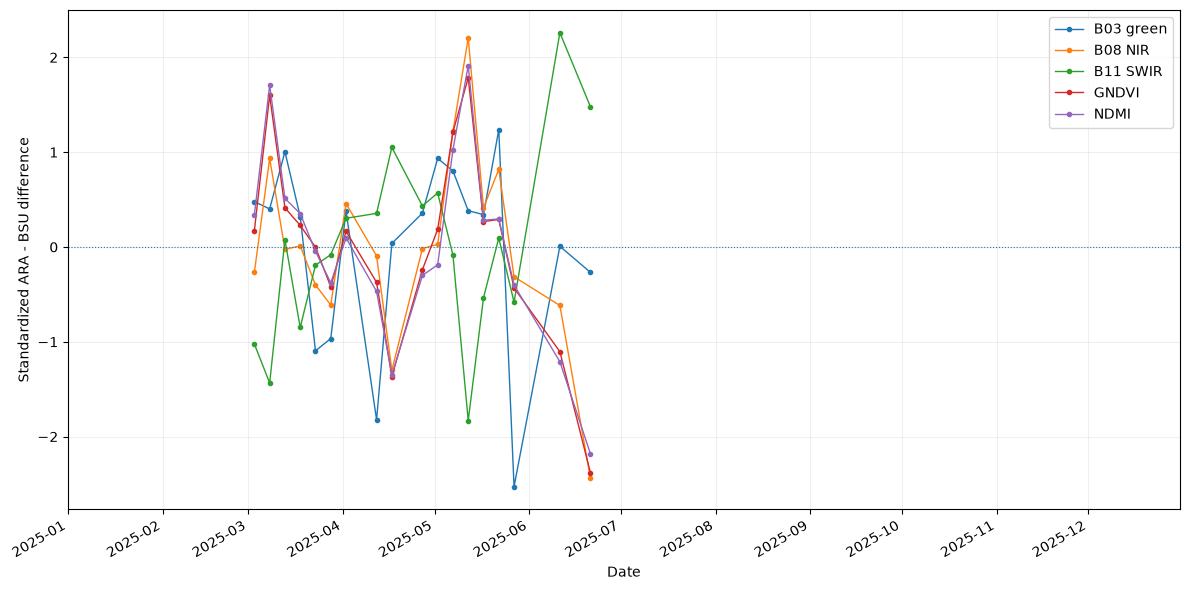

,dB03,dB08,dB11,dGNDVI,dNDMI
dB03,1.00,0.35,-0.03,0.37,0.36
dB08,0.35,1.00,-0.67,0.94,0.92
dB11,-0.03,-0.67,1.00,-0.79,-0.84
dGNDVI,0.37,0.94,-0.79,1.00,0.99
dNDMI,0.36,0.92,-0.84,0.99,1.00


done with cell


In [45]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

# ------------------------------------------------------------
# DIAGNOSTIC CELL: what drives the ARA - BSU GNDVI/NDMI differences?
# ------------------------------------------------------------

start_date = pd.Timestamp("2025-01-01")
end_date   = pd.Timestamp("2025-12-31")

ara_gdf = ConstantObjects.gdf_box_plots_2_3_1A_1B
bsu_gdf = ConstantObjects.gdf_box_plots_4_5
weeds_gdf = ConstantObjects.gdf_box_milpa1

def mean_band_over_aoi(raster_file, gdf):
    """Mean raster value within a GeoDataFrame AOI."""
    with rasterio.open(raster_file) as src:

        # Put AOI into raster CRS
        gdf_raster = gdf.to_crs(src.crs)

        geoms = [geom.__geo_interface__
                 for geom in gdf_raster.geometry]

        data, _ = mask(
            src,
            geoms,
            crop=True,
            filled=False
        )

        arr = data[0]

        # masked-array handling
        if np.ma.isMaskedArray(arr):
            vals = arr.compressed()
        else:
            vals = arr[np.isfinite(arr)]

        # Sentinel reflectance products commonly use 0 as nodata
        vals = vals[vals != 0]

        if len(vals) == 0:
            return np.nan

        return float(np.mean(vals))


def find_band_file(date, band):
    """
    Find the Sentinel-2 source band for the Villanueva site.
    Site is in MGRS tile 14QQG.
    """
    date_string = pd.Timestamp(date).strftime("%Y-%m-%d")
    tile = "14QQG"

    patterns = [
        f"**/{tile}_{date_string}_{band}.jp2",
        f"**/{tile}_{date_string}_{band}.tif",
        f"**/{tile}_{date_string}_{band}.tiff",
        f"**/*{tile}*{date_string}*{band}*.jp2",
        f"**/*{tile}*{date_string}*{band}*.tif",
        f"**/*{tile}*{date_string}*{band}*.tiff",
    ]

    hits = []

    for pattern in patterns:
        hits.extend(glob.glob(pattern, recursive=True))

    # remove duplicates while preserving order
    hits = list(dict.fromkeys(hits))

    hits = [
        x for x in hits
        if "ndmi" not in x.lower()
        and "gndvi" not in x.lower()
    ]

    if len(hits) == 0:
        print(f"{date_string} {band}: no 14QQG file found")
        return None

    if len(hits) > 1:
        print(f"{date_string} {band}: found {len(hits)} 14QQG files; using")
        print("   ", hits[0])

    return hits[0]

    

# Use acquisition dates that already survived your NDMI/GNDVI processing
df2025 = df.loc[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
].copy()

rows_band = []


for date in df2025["date"]:

    row = {"date": date}

    for band in ["B03", "B08", "B11"]:

        band_file = find_band_file(date, band)

        if band_file is None:
            print(f"{date.date()} {band}: file not found")
            row[f"{band}_ARA"] = np.nan
            row[f"{band}_BSU"] = np.nan
            row[f"d{band}"] = np.nan
            continue

        ara_mean = mean_band_over_aoi(band_file, ara_gdf)
        bsu_mean = mean_band_over_aoi(band_file, bsu_gdf)

        weeds_mean = mean_band_over_aoi(band_file, weeds_gdf)

        row[f"{band}_WEEDS"] = weeds_mean
        row[f"d{band}_ARA_WEEDS"] = ara_mean - weeds_mean

        row[f"{band}_ARA"] = ara_mean
        row[f"{band}_BSU"] = bsu_mean
        row[f"d{band}"] = ara_mean - bsu_mean

    rows_band.append(row)


band_df = pd.DataFrame(rows_band)


# Existing index differences
band_df["dGNDVI"] = (
    df2025["gndvi_plots_2_3_1A_1B"].to_numpy()
    - df2025["gndvi_plots_4_5"].to_numpy()
)

band_df["dNDMI"] = (
    df2025["ndmi_plots_2_3_1A_1B"].to_numpy()
    - df2025["ndmi_plots_4_5"].to_numpy()
)
band_df["cloudy"] = (
    df2025["cloudy"].to_numpy()
)

# ------------------------------------------------------------
# Normalize the raw-band differences before plotting.
#
# B03/B08/B11 are reflectance/DN values and GNDVI/NDMI are indices,
# so their absolute y-scales are not directly comparable.
#
# Z-scoring lets us compare whether their SHAPES track each other.
# ------------------------------------------------------------

columns = ["dB03", "dB08", "dB11", "dGNDVI", "dNDMI"]

plot_df = band_df[["date"] + columns].copy()

for col in columns:
    mean = plot_df[col].mean()
    sd = plot_df[col].std()

    if sd > 0:
        plot_df[col + "_z"] = (plot_df[col] - mean) / sd
    else:
        plot_df[col + "_z"] = np.nan


fig, ax = plt.subplots(figsize=(12, 6))

for col, label in [
    ("dB03_z",   "B03 green"),
    ("dB08_z",   "B08 NIR"),
    ("dB11_z",   "B11 SWIR"),
    ("dGNDVI_z", "GNDVI"),
    ("dNDMI_z",  "NDMI"),
]:
    ax.plot(
        plot_df["date"],
        plot_df[col],
        marker="o",
        markersize=3,
        linewidth=1,
        label=label
    )

ax.axhline(0, linewidth=0.8, linestyle=":")

ax.set_xlim(start_date, end_date)
ax.set_ylabel("Standardized ARA - BSU difference")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.2)

fig.autofmt_xdate()
fig.tight_layout()

plt.show()


# Correlation matrix: useful numerical companion to the plot
display(
    band_df[columns].corr().round(2)
)
print ("done with cell")

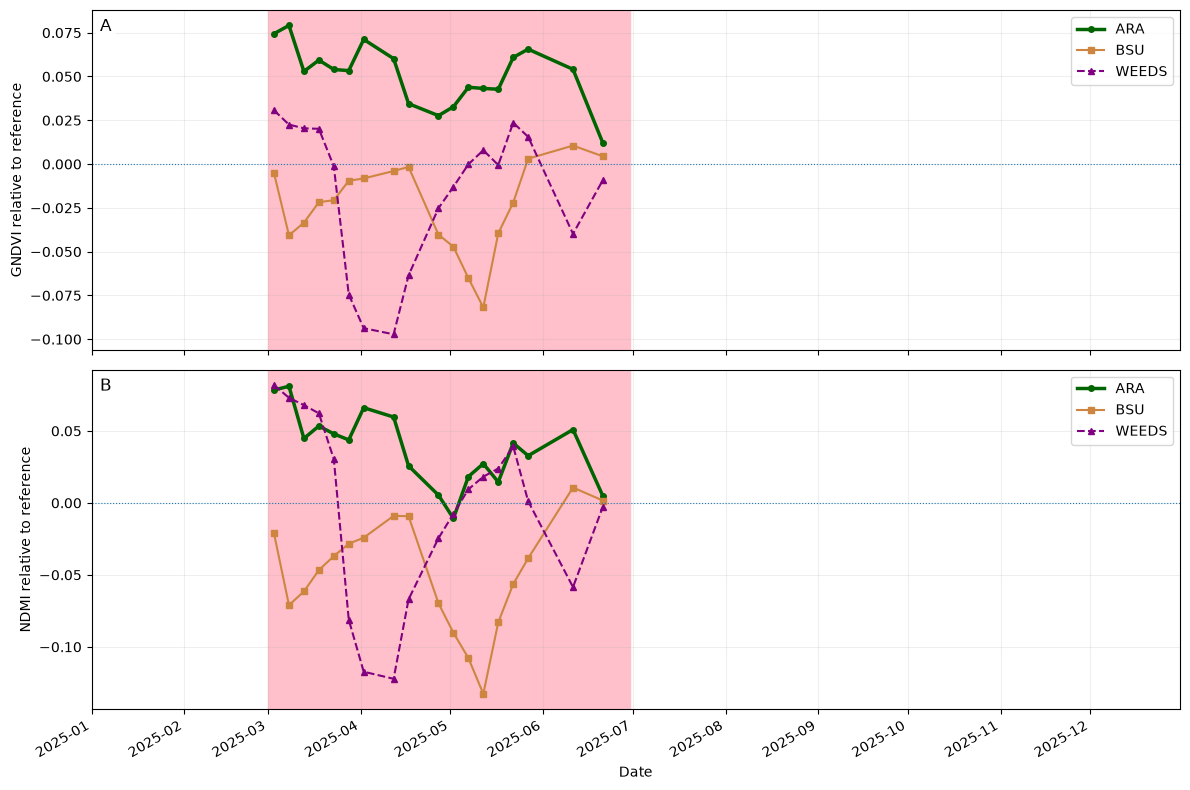

In [46]:
# Add visible-scene brightness to band_df
brightness_2025 = df.loc[
    (df["date"] >= start_date) &
    (df["date"] <= end_date),
    [
        "date",
        "red_green_blue_average",
        "gndvi_plots_2_3_1A_1B",
        "gndvi_plots_4_5",
        "gndvi_milpa1",
        "ndmi_plots_2_3_1A_1B",
        "ndmi_plots_4_5",
        "ndmi_milpa1"

    ]
].copy()

nir_plot_df = band_df.merge(
    brightness_2025,
    on="date",
    how="left"
)

# band_df already supplied this column
nir_plot_df = nir_plot_df.loc[
    nir_plot_df["cloudy"] == 0
].copy()




fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

ax_gndvi = axes[0]
ax_ndmi = axes[1]

# -----------------------------
# Panel A: GNDVI
# -----------------------------

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_plots_2_3_1A_1B"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="ARA",
    **ara_style
)

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_plots_4_5"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="BSU",
    **bsu_style
)

ax_gndvi.plot(
    nir_plot_df["date"],
    nir_plot_df["gndvi_milpa1"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="WEEDS",
    **weeds_style
)

ax_gndvi.set_ylabel("GNDVI relative to reference")
ax_gndvi.set_xlim(start_date, end_date)
ax_gndvi.axhline(0, linewidth=0.8, linestyle=":")
ax_gndvi.grid(alpha=0.2)

MatPlotLibUtils.indicate_seasons_box(
    startDate2025,
    endDate2025,
    ax_gndvi,
    my_label="Dry season",
    my_color="pink",
    line_style="none"
)

ax_gndvi.legend(loc="upper right")

ax_gndvi.annotate(
    "A",
    xy=(0, 1),
    xycoords="axes fraction",
    xytext=(0.5, -0.5),
    textcoords="offset fontsize",
    fontsize="large",
    verticalalignment="top",
    bbox=dict(facecolor="1.", edgecolor="none", pad=3.0)
)


# -----------------------------
# Panel B: NDMI
# -----------------------------

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_plots_2_3_1A_1B"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="ARA",
    **ara_style
)

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_plots_4_5"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="BSU",
    **bsu_style
)

ax_ndmi.plot(
    nir_plot_df["date"],
    nir_plot_df["ndmi_milpa1"],
    #marker="s",
    #markersize=3,
    #linewidth=1,
    label="WEEDS",
    **weeds_style
)

ax_ndmi.set_ylabel("NDMI relative to reference")
ax_ndmi.set_xlabel("Date")
ax_ndmi.set_xlim(start_date, end_date)
ax_ndmi.axhline(0, linewidth=0.8, linestyle=":")
ax_ndmi.grid(alpha=0.2)

MatPlotLibUtils.indicate_seasons_box(
    startDate2025,
    endDate2025,
    ax_ndmi,
    my_label="Dry season",
    my_color="pink",
    line_style="none"
)

ax_ndmi.legend(loc="upper right")

ax_ndmi.annotate(
    "B",
    xy=(0, 1),
    xycoords="axes fraction",
    xytext=(0.5, -0.5),
    textcoords="offset fontsize",
    fontsize="large",
    verticalalignment="top",
    bbox=dict(facecolor="1.", edgecolor="none", pad=3.0)
)

fig.autofmt_xdate()
fig.tight_layout()

plt.show()
fig.savefig("ndmi_gndvi_2025.png", dpi=300, bbox_inches="tight")


In [47]:
from scipy import stats
import pandas as pd
import numpy as np

ds_start = pd.Timestamp(Constants.warmDryStart2025)
ds_end   = pd.Timestamp(Constants.warmDryEnd2025)

indices = df.loc[
    (df["date"] >= ds_start) &
    (df["date"] <= ds_end),
    [
        "date",
        "gndvi_plots_2_3_1A_1B",
        "gndvi_plots_4_5",
        "gndvi_milpa1",
        "ndmi_plots_2_3_1A_1B",
        "ndmi_plots_4_5",
        "ndmi_milpa1"
       
    ]
].copy()

nir = band_df.loc[
    (band_df["date"] >= ds_start) &
    (band_df["date"] <= ds_end),
    [
        "date",
        "B03_ARA",
        "B03_BSU",
        "B08_ARA",
        "B08_BSU",
        "B08_WEEDS",
        "B11_ARA",
        "B11_BSU",
        "cloudy"
    ]
].copy()

ds = nir.merge(indices, on="date", how="inner")

# Exclude acquisitions already flagged as cloudy
ds = ds.loc[ds["cloudy"] == 0].copy()

print("Dry season:", ds_start.date(), "to", ds_end.date())
print()


def paired_comparison(name, ara, comparison):

    valid = pd.DataFrame({
        "ARA": ara,
        "comparison": comparison
    }).dropna()

    delta = valid["ARA"] - valid["comparison"]

    # Directional hypothesis: ARA > comparison
    t_result = stats.ttest_rel(
        valid["ARA"],
        valid["comparison"],
        alternative="greater"
    )

    w = stats.wilcoxon(
        valid["ARA"],
        valid["comparison"],
        alternative="greater"
    )

    return {
        "comparison": name,
        "n": len(delta),
        "mean_delta": delta.mean(),
        "median_delta": delta.median(),
        "ARA_higher": (delta > 0).sum(),
        "t": t_result.statistic,
        "p_one_sided": t_result.pvalue,
        "p_wilcoxon": w.pvalue
    }


results = []

# ARA - BSU
results.append(
    paired_comparison(
        "B03 Green: BSU - ARA",
        ds["B03_BSU"], 
        ds["B03_ARA"]#,
      
        #ds["B03_ARA"],
        #ds["B03_BSU"]
    )
)

results.append(
    paired_comparison(
        "B08 NIR: ARA - BSU",
        ds["B08_ARA"],
        ds["B08_BSU"]
    )
)

results.append(
    paired_comparison(
        "B11 SWIR: BSU - ARA",
        ds["B11_BSU"],
        ds["B11_ARA"]#,

        #ds["B11_ARA"],
        #ds["B11_BSU"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: ARA - BSU",
        ds["gndvi_plots_2_3_1A_1B"],
        ds["gndvi_plots_4_5"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: WEEDS - BSU",
        ds["gndvi_milpa1"],
        ds["gndvi_plots_4_5"]
    )
)

results.append(
    paired_comparison(
        "NDMI: ARA - BSU",
        ds["ndmi_plots_2_3_1A_1B"],
        ds["ndmi_plots_4_5"]
    )
)

# ARA - WEEDS
results.append(
    paired_comparison(
        "B08: ARA - WEEDS",
        ds["B08_ARA"],
        ds["B08_WEEDS"]
    )
)

results.append(
    paired_comparison(
        "NDMI: ARA - WEEDS",
        ds["ndmi_plots_2_3_1A_1B"],
        ds["ndmi_milpa1"]
    )
)

results.append(
    paired_comparison(
        "GNDVI: ARA - WEEDS",
        ds["gndvi_plots_2_3_1A_1B"],
        ds["gndvi_milpa1"]
    )
)



results_df = pd.DataFrame(results)

display(results_df)
results_df.to_csv("comparison-significance.csv", index=False)
#provide this as supplementary data:
ds.to_csv("dry-season-data-2025.csv", index=False)


Dry season: 2025-03-01 to 2025-06-30



,comparison,n,mean_delta,median_delta,ARA_higher,t,p_one_sided,p_wilcoxon
0,B03 Green: BSU - ARA,18,0.592929,-5.127273,6,0.153567,4.398798e-01,0.752460
1,B08 NIR: ARA - BSU,18,783.981818,777.681818,18,11.189477,1.455287e-09,0.000004
2,B11 SWIR: BSU - ARA,18,92.750000,93.000000,16,5.118709,4.277141e-05,0.000126
3,GNDVI: ARA - BSU,18,0.074702,0.079482,18,11.232285,1.373855e-09,0.000004
4,GNDVI: WEEDS - BSU,18,0.008099,0.026766,12,0.613462,2.738459e-01,0.289921
5,NDMI: ARA - BSU,18,0.086633,0.087589,18,9.593271,1.417822e-08,0.000004
6,B08: ARA - WEEDS,18,745.374126,448.776224,15,4.071454,3.971442e-04,0.000053
7,NDMI: ARA - WEEDS,18,0.042158,0.008945,13,2.708972,7.446689e-03,0.007965
8,GNDVI: ARA - WEEDS,18,0.066603,0.047911,18,6.521190,2.614561e-06,0.000004


In [48]:
# Got 17 rain free days in every single DS for all three years. running this diagnostic as a sanity check
for year in [2023, 2025, 2026]:

    start = pd.Timestamp(f"{year}-03-01")
    end   = pd.Timestamp(f"{year}-06-30")

    tmp = df.loc[
        (df["date"] >= start) &
        (df["date"] <= end),
        ["date", "cloudy", "red_green_blue_average"]
    ].copy()

    print("\n================")
    print(year)
    print("================")
    print("Total acquisitions:", len(tmp))
    print("Cloud-free:", (tmp["cloudy"] == 0).sum())
    print("Cloudy:", (tmp["cloudy"] == 1).sum())

    display(tmp)


2023
Total acquisitions: 18
Cloud-free: 18
Cloudy: 0


,date,cloudy,red_green_blue_average
13,2023-03-04,0,1810.274194
14,2023-03-09,0,1980.526882
15,2023-03-14,0,1917.370968
16,2023-03-24,0,1787.962366
17,2023-04-03,0,1731.978495
18,2023-04-18,0,1824.795699
19,2023-04-23,0,2005.806452
20,2023-04-28,0,1878.311828
21,2023-05-08,0,1773.241935
22,2023-05-13,0,1904.317204



2025
Total acquisitions: 18
Cloud-free: 18
Cloudy: 0


,date,cloudy,red_green_blue_average
50,2025-03-03,0,1745.505376
51,2025-03-08,0,1762.854839
52,2025-03-13,0,1778.586022
53,2025-03-18,0,1784.155914
54,2025-03-23,0,1805.413978
55,2025-03-28,0,1927.021505
56,2025-04-02,0,1827.032258
57,2025-04-12,0,1771.741935
58,2025-04-17,0,1997.408602
59,2025-04-27,0,1811.704301



2026
Total acquisitions: 16
Cloud-free: 16
Cloudy: 0


,date,cloudy,red_green_blue_average
68,2026-03-03,0,2644.225806
69,2026-03-18,0,1936.155914
70,2026-03-23,0,2690.693548
71,2026-03-28,0,1943.150538
72,2026-04-02,0,1772.387097
73,2026-04-12,0,1873.930108
74,2026-04-17,0,2309.467742
75,2026-04-27,0,1855.204301
76,2026-05-17,0,3452.204301
77,2026-05-22,0,1833.897849


In [49]:
from scipy import stats
import pandas as pd
import numpy as np

# ============================================================
# Multi-year dry-season comparison table
# Years: 2023, 2025, 2026
#
# Same analysis for every year:
#   - March 1 to June 30
#   - exclude cloudy acquisitions
#   - acquisition date is the paired observation
#   - two-sided paired tests
# ============================================================

years = [2023, 2025, 2026]


def paired_comparison(year, name, plot1, plot2):

    valid = pd.DataFrame({
        "plot1": plot1,
        "plot2": plot2
    }).dropna()

    delta = valid["plot1"] - valid["plot2"]

    if len(delta) < 2:
        return {
            "Contrast": name,
            "Year": year,
            "n": len(delta),
            "Mean Δ": np.nan,
            "Δ > 0 (n)": np.nan,
            "p, paired t": np.nan,
            "p, Wilcoxon": np.nan
        }

    # Two-sided paired t-test
    t_result = stats.ttest_rel(
        valid["plot1"],
        valid["plot2"],
        alternative="two-sided"
    )

    # Two-sided Wilcoxon signed-rank test
    try:
        w_result = stats.wilcoxon(
            valid["plot1"],
            valid["plot2"],
            alternative="two-sided"
        )
        p_wilcoxon = w_result.pvalue

    except ValueError:
        p_wilcoxon = np.nan

    return {
        "Contrast": name,
        "Year": year,
        "n": len(delta),
        "Mean Δ": delta.mean(),
        "Δ > 0 (n)": int((delta > 0).sum()),
        "p, paired t": t_result.pvalue,
        "p, Wilcoxon": p_wilcoxon
    }


# ============================================================
# Run all years
# ============================================================

all_results = []

for year in years:

    ds_start = pd.Timestamp(f"{year}-03-01")
    ds_end   = pd.Timestamp(f"{year}-06-30")

    ds_year = df.loc[
        (df["date"] >= ds_start) &
        (df["date"] <= ds_end),
        [
            "date",
            "gndvi_plots_2_3_1A_1B",
            "gndvi_plots_4_5",
            "gndvi_milpa1",
            "ndmi_plots_2_3_1A_1B",
            "ndmi_plots_4_5",
            "ndmi_milpa1",
            "cloudy"
        ]
    ].copy()

    # Exclude cloudy acquisitions
    ds_year = ds_year.loc[
        ds_year["cloudy"] == 0
    ].copy()

    print(
        year,
        "non-cloudy acquisitions:",
        len(ds_year)
    )

    # --------------------------------------------------------
    # ARA - BSU
    # --------------------------------------------------------

    all_results.append(
        paired_comparison(
            year,
            "GNDVI_ARA - GNDVI_BSU",
            ds_year["gndvi_plots_2_3_1A_1B"],
            ds_year["gndvi_plots_4_5"]
        )
    )

    all_results.append(
        paired_comparison(
            year,
            "NDMI_ARA - NDMI_BSU",
            ds_year["ndmi_plots_2_3_1A_1B"],
            ds_year["ndmi_plots_4_5"]
        )
    )

    # --------------------------------------------------------
    # ARA - WEEDS
    # --------------------------------------------------------

    all_results.append(
        paired_comparison(
            year,
            "GNDVI_ARA - GNDVI_WEEDS",
            ds_year["gndvi_plots_2_3_1A_1B"],
            ds_year["gndvi_milpa1"]
        )
    )

    all_results.append(
        paired_comparison(
            year,
            "NDMI_ARA - NDMI_WEEDS",
            ds_year["ndmi_plots_2_3_1A_1B"],
            ds_year["ndmi_milpa1"]
        )
    )


# ============================================================
# Compact manuscript-style table
# ============================================================

table_df = pd.DataFrame(all_results)

# Keep the years together within each contrast
contrast_order = [
    "GNDVI_ARA - GNDVI_BSU",
    "NDMI_ARA - NDMI_BSU",
    "GNDVI_ARA - GNDVI_WEEDS",
    "NDMI_ARA - NDMI_WEEDS"
]

table_df["Contrast"] = pd.Categorical(
    table_df["Contrast"],
    categories=contrast_order,
    ordered=True
)

table_df = table_df.sort_values(
    ["Contrast", "Year"]
).reset_index(drop=True)

# Fewer significant figures for manuscript display
table_df["Mean Δ"] = table_df["Mean Δ"].map(
    lambda x: f"{x:.2g}" if pd.notna(x) else ""
)

table_df["p, paired t"] = table_df["p, paired t"].map(
    lambda x: f"{x:.1E}" if pd.notna(x) else ""
)

table_df["p, Wilcoxon"] = table_df["p, Wilcoxon"].map(
    lambda x: f"{x:.1E}" if pd.notna(x) else ""
)

display(table_df)

# Optional export
table_df.to_csv(
    "dry-season-GNDVI-NDMI-comparisons-2023-2025-2026.csv",
    index=False
)

2023 non-cloudy acquisitions: 18
2025 non-cloudy acquisitions: 18
2026 non-cloudy acquisitions: 16


,Contrast,Year,n,Mean Δ,Δ > 0 (n),"p, paired t","p, Wilcoxon"
0,GNDVI_ARA - GNDVI_BSU,2023,18,0.023,13,3.1E-02,4.3E-02
1,GNDVI_ARA - GNDVI_BSU,2025,18,0.075,18,2.7E-09,7.6E-06
2,GNDVI_ARA - GNDVI_BSU,2026,16,0.022,12,1.8E-03,3.4E-03
3,NDMI_ARA - NDMI_BSU,2023,18,0.027,12,3.4E-02,5.4E-02
4,NDMI_ARA - NDMI_BSU,2025,18,0.087,18,2.8E-08,7.6E-06
5,NDMI_ARA - NDMI_BSU,2026,16,0.018,12,4.1E-02,3.4E-02
6,GNDVI_ARA - GNDVI_WEEDS,2023,18,-0.013,7,8.8E-02,7.4E-02
7,GNDVI_ARA - GNDVI_WEEDS,2025,18,0.067,18,5.2E-06,7.6E-06
8,GNDVI_ARA - GNDVI_WEEDS,2026,16,0.033,10,1.2E-01,2.3E-01
9,NDMI_ARA - NDMI_WEEDS,2023,18,-0.042,3,1.5E-04,3.3E-04


In [61]:


from scipy import stats
import pandas as pd
import numpy as np

# ============================================================
# BACI analysis for dry-season GNDVI and NDMI
#
# BEFORE: pooled dry-season acquisitions from 2022 + 2023
# AFTER:  2025 dry-season acquisitions
#
# For each acquisition:
#   d_t = value_plot1,t - value_plot2,t
#
# BACI = mean(d_after) - mean(d_before)
#
# Significance:
#   - Welch's independent two-sample t-test
#   - Wilcoxon rank-sum equivalent: Mann-Whitney U
#
# Cloudy acquisitions are excluded before constructing contrasts.
# ============================================================

before_years = [2022, 2023]
after_year = 2026


def get_dry_season(year):
    """Return cloud-free March 1-June 30 acquisitions for one year."""

    ds_start = pd.Timestamp(f"{year}-03-01")
    ds_end   = pd.Timestamp(f"{year}-06-30")

    ds = df.loc[
        (df["date"] >= ds_start) &
        (df["date"] <= ds_end),
        [
            "date",
            "gndvi_plots_2_3_1A_1B",
            "gndvi_plots_4_5",
            "gndvi_milpa1",
            "ndmi_plots_2_3_1A_1B",
            "ndmi_plots_4_5",
            "ndmi_milpa1",
            "cloudy"
        ]
    ].copy()

    ds = ds.loc[
        ds["cloudy"] == 0
    ].copy()

    ds["year"] = year

    return ds


def make_scene_contrast(ds, plot1_col, plot2_col):
    """
    Construct the within-scene spatial contrast:
        d_t = plot1_t - plot2_t
    """

    valid = ds[
        ["date", plot1_col, plot2_col]
    ].dropna().copy()

    valid["d"] = (
        valid[plot1_col] -
        valid[plot2_col]
    )

    return valid["d"].to_numpy()


def baci_comparison(
    name,
    before_df,
    after_df,
    plot1_col,
    plot2_col
):

    # --------------------------------------------------------
    # First construct paired spatial contrasts within each scene
    # --------------------------------------------------------

    d_before = make_scene_contrast(
        before_df,
        plot1_col,
        plot2_col
    )

    d_after = make_scene_contrast(
        after_df,
        plot1_col,
        plot2_col
    )

    if len(d_before) < 2 or len(d_after) < 2:
        return {
            "Contrast": name,
            "n before": len(d_before),
            "n after": len(d_after),
            "Mean Δ before": np.nan,
            "Mean Δ after": np.nan,
            "BACI": np.nan,
            "p, Welch": np.nan,
            "p, rank-sum": np.nan
        }

    # --------------------------------------------------------
    # BACI effect
    # --------------------------------------------------------

    mean_before = np.mean(d_before)
    mean_after  = np.mean(d_after)

    baci = mean_after - mean_before
    print(name, "BACI full precision =", f"{baci:.8E}")
    #print(f"{baci:.2E}")
    # --------------------------------------------------------
    # Welch's independent two-sample t-test
    #
    # Tests whether the mean within-scene contrast changed
    # between BEFORE and AFTER.
    # --------------------------------------------------------

    welch = stats.ttest_ind(
        d_after,
        d_before,
        equal_var=False,
        alternative="two-sided"
    )

    # --------------------------------------------------------
    # Non-parametric comparison:
    # Mann-Whitney U = Wilcoxon rank-sum test
    #
    # Unlike the old analysis, this is NOT signed-rank,
    # because BEFORE and AFTER are independent samples.
    # --------------------------------------------------------

    try:
        rank_sum = stats.mannwhitneyu(
            d_after,
            d_before,
            alternative="two-sided",
            method="auto"
        )
        p_rank_sum = rank_sum.pvalue

    except ValueError:
        p_rank_sum = np.nan

    return {
        "Contrast": name,
        "n before": len(d_before),
        "n after": len(d_after),
        "Mean Δ before": mean_before,
        "Mean Δ after": mean_after,
        "BACI": baci,
        "p, Welch": welch.pvalue,
        "p, rank-sum": p_rank_sum
    }


# ============================================================
# Build BEFORE and AFTER datasets
# ============================================================

before_parts = []

for year in before_years:
    ds_year = get_dry_season(year)

    print(
        year,
        "non-cloudy acquisitions:",
        len(ds_year)
    )

    before_parts.append(ds_year)


before_df = pd.concat(
    before_parts,
    ignore_index=True
)

after_df = get_dry_season(after_year)
print("\nBEFORE dates:")
for year in before_years:
    tmp = get_dry_season(year)
    print(year, tmp["date"].dt.strftime("%Y-%m-%d").tolist())

print("\nAFTER dates:")
print(after_year, after_df["date"].dt.strftime("%Y-%m-%d").tolist())
print(
    after_year,
    "non-cloudy acquisitions:",
    len(after_df)
)

print()
print(
    "Pooled BEFORE acquisitions:",
    len(before_df)
)

print(
    "AFTER acquisitions:",
    len(after_df)
)


# ============================================================
# Run BACI contrasts
# ============================================================

results = []

# ------------------------------------------------------------
# ARA - BSU
# ------------------------------------------------------------

results.append(
    baci_comparison(
        "GNDVI_ARA - GNDVI_BSU",
        before_df,
        after_df,
        "gndvi_plots_2_3_1A_1B",
        "gndvi_plots_4_5"
    )
)

results.append(
    baci_comparison(
        "NDMI_ARA - NDMI_BSU",
        before_df,
        after_df,
        "ndmi_plots_2_3_1A_1B",
        "ndmi_plots_4_5"
    )
)

# ------------------------------------------------------------
# ARA - WEEDS
# ------------------------------------------------------------

results.append(
    baci_comparison(
        "GNDVI_ARA - GNDVI_WEEDS",
        before_df,
        after_df,
        "gndvi_plots_2_3_1A_1B",
        "gndvi_milpa1"
    )
)

results.append(
    baci_comparison(
        "NDMI_ARA - NDMI_WEEDS",
        before_df,
        after_df,
        "ndmi_plots_2_3_1A_1B",
        "ndmi_milpa1"
    )
)


# ============================================================
# Compact manuscript-style table
# ============================================================

table_df = pd.DataFrame(results)

contrast_order = [
    "GNDVI_ARA - GNDVI_BSU",
    "NDMI_ARA - NDMI_BSU",
    "GNDVI_ARA - GNDVI_WEEDS",
    "NDMI_ARA - NDMI_WEEDS"
]

table_df["Contrast"] = pd.Categorical(
    table_df["Contrast"],
    categories=contrast_order,
    ordered=True
)

table_df = table_df.sort_values(
    "Contrast"
).reset_index(drop=True)


# ------------------------------------------------------------
# Compact formatting
# ------------------------------------------------------------

for col in [
    "Mean Δ before",
    "Mean Δ after",
    "BACI"
]:
    table_df[col] = table_df[col].map(
        lambda x: f"{x:.2g}" if pd.notna(x) else ""
    )

for col in [
    "p, Welch",
    "p, rank-sum"
]:
    table_df[col] = table_df[col].map(
        lambda x: f"{x:.1E}" if pd.notna(x) else ""
    )

#table_df["BACI"].apply(lambda x: f"{x:.2E}")
display(table_df)


# ============================================================
# Optional export
# ============================================================

table_df.to_csv(
    "BACI-dry-season-GNDVI-NDMI-2025-vs-2022-2023.csv",
    index=False
)



2022 non-cloudy acquisitions: 13
2023 non-cloudy acquisitions: 18

BEFORE dates:
2022 ['2022-03-04', '2022-03-14', '2022-03-29', '2022-04-13', '2022-04-23', '2022-05-03', '2022-05-08', '2022-05-13', '2022-05-18', '2022-05-23', '2022-06-07', '2022-06-12', '2022-06-27']
2023 ['2023-03-04', '2023-03-09', '2023-03-14', '2023-03-24', '2023-04-03', '2023-04-18', '2023-04-23', '2023-04-28', '2023-05-08', '2023-05-13', '2023-05-18', '2023-05-23', '2023-05-28', '2023-06-07', '2023-06-12', '2023-06-17', '2023-06-22', '2023-06-27']

AFTER dates:
2026 ['2026-03-03', '2026-03-18', '2026-03-23', '2026-03-28', '2026-04-02', '2026-04-12', '2026-04-17', '2026-04-27', '2026-05-17', '2026-05-22', '2026-05-27', '2026-06-01', '2026-06-06', '2026-06-16', '2026-06-21', '2026-06-26']
2026 non-cloudy acquisitions: 16

Pooled BEFORE acquisitions: 31
AFTER acquisitions: 16
GNDVI_ARA - GNDVI_BSU BACI full precision = 3.83170947E-03
NDMI_ARA - NDMI_BSU BACI full precision = -1.04559368E-03
GNDVI_ARA - GNDVI_WEEDS 

,Contrast,n before,n after,Mean Δ before,Mean Δ after,BACI,"p, Welch","p, rank-sum"
0,GNDVI_ARA - GNDVI_BSU,31,16,0.018,0.022,0.0038,6.6E-01,7.3E-01
1,NDMI_ARA - NDMI_BSU,31,16,0.019,0.018,-0.001,9.3E-01,9.2E-01
2,GNDVI_ARA - GNDVI_WEEDS,31,16,-0.018,0.033,0.051,2.8E-02,3.2E-02
3,NDMI_ARA - NDMI_WEEDS,31,16,-0.045,0.028,0.073,1.5E-02,2.4E-02


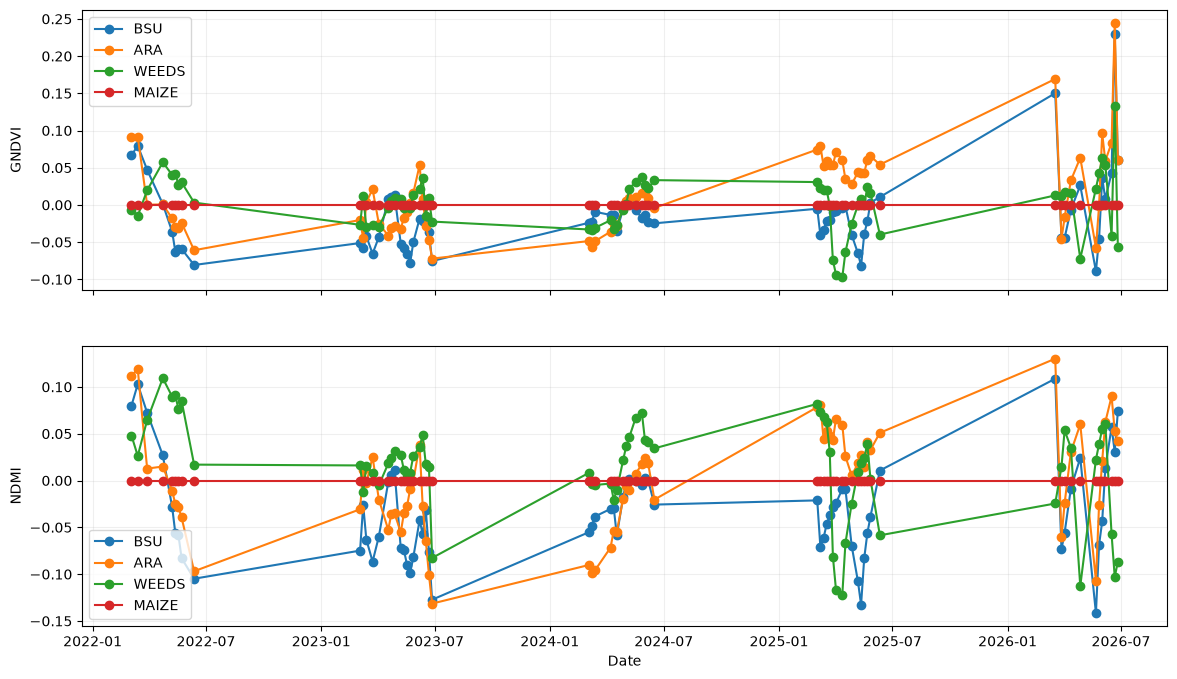

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# GNDVI
axes[0].plot(df["date"], df["gndvi_plots_4_5"],
             marker="o", label="BSU")
axes[0].plot(df["date"], df["gndvi_plots_2_3_1A_1B"],
             marker="o", label="ARA")
axes[0].plot(df["date"], df["gndvi_milpa1"],
             marker="o", label="WEEDS")
axes[0].plot(df["date"], df["gndvi_milpa_vecino"],
             marker="o", label="MAIZE")

axes[0].set_ylabel("GNDVI")
axes[0].legend()
axes[0].grid(alpha=0.2)

# NDMI
axes[1].plot(df["date"], df["ndmi_plots_4_5"],
             marker="o", label="BSU")
axes[1].plot(df["date"], df["ndmi_plots_2_3_1A_1B"],
             marker="o", label="ARA")
axes[1].plot(df["date"], df["ndmi_milpa1"],
             marker="o", label="WEEDS")
axes[1].plot(df["date"], df["ndmi_milpa_vecino"],
             marker="o", label="MAIZE")

axes[1].set_ylabel("NDMI")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.2)




In [40]:
ndmi_analysis = df.loc[
    (df["date"] >= "2022-01-03") &
    (df["date"] <= "2026-07-31"),
    [
        "date",
        "ndmi_plots_2_3_1A_1B",
        "ndmi_plots_4_5",
        "ndmi_milpa1",

        "gndvi_plots_2_3_1A_1B",
        "gndvi_plots_4_5",
        "gndvi_milpa1"
    ]
].copy()

ndmi_analysis = ndmi_analysis.rename(columns={
    "ndmi_plots_2_3_1A_1B": "ARA_NDMI",
    "ndmi_plots_4_5": "BSU_NDMI",
    "ndmi_milpa1": "WEEDS_NDMI",

    "gndvi_plots_2_3_1A_1B": "ARA_GNDVI",
    "gndvi_plots_4_5": "BSU_GNDVI",
    "gndvi_milpa1": "WEEDS_GNDVI"
})



ndmi_analysis.to_csv(
    "ndmi-gndvi-2022-2026.csv",
    index=False
)